In [1]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from rasterio.windows import from_bounds

In [3]:
tif_file = "IslandsDEMv1.0_2x2m_zmasl_isn93_57.tif"

xmin = 369702.8
xmax = 374398.8
ymin = 407778.9
ymax = 411690.2


with rasterio.open(
    tif_file
) as src:

    window = from_bounds(
        xmin,
        ymin,
        xmax,
        ymax,
        src.transform
    )

    # read subset
    dem = src.read(1, window=window)

    # subset transform
    transform = src.window_transform(window)

    # copy metadata
    profile = src.profile.copy()

    # update metadata
    profile.update({
        "height": dem.shape[0],
        "width": dem.shape[1],
        "transform": transform
    })

    # save subset
    with rasterio.open(
        "subset_dem.tif",
        "w",
        **profile
    ) as dst:

        dst.write(dem, 1)

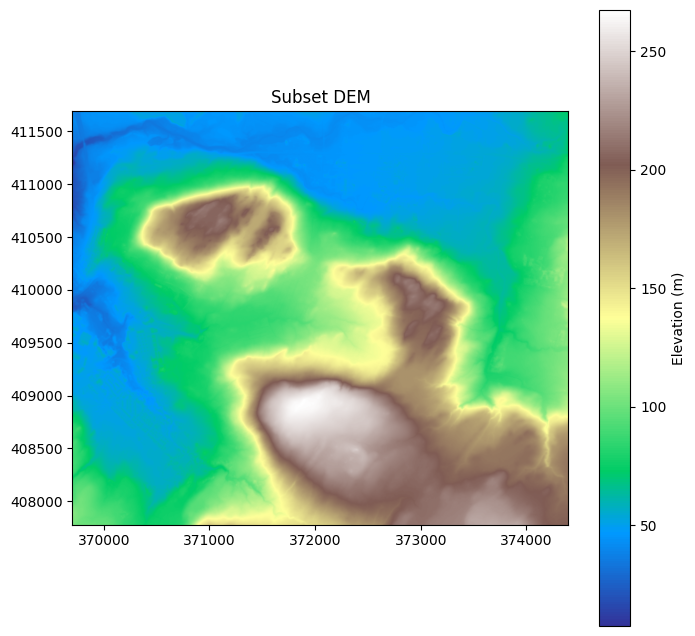

In [4]:
from rasterio.plot import show

fig, ax = plt.subplots(figsize=(8, 8))

img = show(
    dem,
    transform=transform,
    ax=ax,
    cmap="terrain"
)

# add colorbar
cbar = plt.colorbar(
    img.get_images()[0],
    ax=ax
)

cbar.set_label("Elevation (m)")

ax.set_title("Subset DEM")

plt.show()

In [5]:
with rasterio.open("subset_dem.tif") as src:

    print(src.crs)
    print(src.bounds)
    print(src.res)
    print(src.width, src.height)

EPSG:3057
BoundingBox(left=369702.8, bottom=407778.2, right=374398.8, top=411690.2)
(2.0, 2.0)
2348 1956
